### 1. Load the Pima Indians Diabetes Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import euclidean, cityblock, cosine

# Load the dataset from sample_data
df = pd.read_csv('/content/sample_data/diabetes.csv')
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2. Identify and Handle Missing/Invalid Values
In this dataset, columns like Glucose, BloodPressure, SkinThickness, Insulin, and BMI should not have zero values. We will replace zeros with NaN and then impute them using the median.

In [2]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Check count of missing values
print("Missing values per column:")
print(df.isnull().sum())

# Impute missing values with median
for col in cols_with_zeros:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values per column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### 3. Correlation Analysis
We'll calculate the correlation matrix and visualize it with a heatmap.

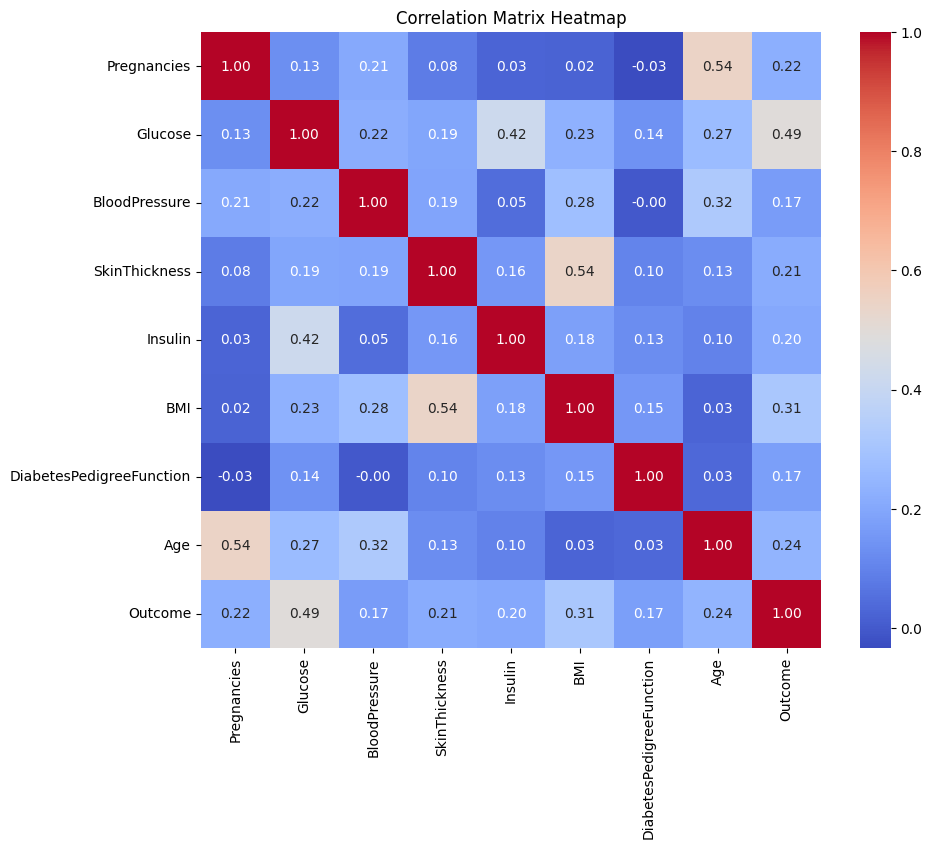

In [3]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

### 4. Distance Measures
Calculating distances between the first two observations.

In [4]:
obs1 = df.iloc[0, :-1].values
obs2 = df.iloc[1, :-1].values

print(f"Euclidean Distance: {euclidean(obs1, obs2):.4f}")
print(f"Manhattan (Cityblock) Distance: {cityblock(obs1, obs2):.4f}")
print(f"Cosine Distance: {cosine(obs1, obs2):.4f}")

Euclidean Distance: 66.9035
Manhattan (Cityblock) Distance: 106.2760
Cosine Distance: 0.0316


### 5. Normalization
Scaling features to a range [0, 1] and comparing the data distributions.

In [5]:
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df.drop(columns=['Outcome'])), columns=df.columns[:-1])

print("Data Before Normalization (Head):")
display(df.drop(columns=['Outcome']).head(3))

print("\nData After Normalization (Head):")
display(df_normalized.head(3))

Data Before Normalization (Head):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32



Data After Normalization (Head):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.352941,0.670968,0.489796,0.304348,0.133413,0.314928,0.234415,0.483333
1,0.058824,0.264516,0.428571,0.239130,0.133413,0.171779,0.116567,0.166667
2,0.470588,0.896774,0.408163,0.239130,0.133413,0.104294,0.253629,0.183333


### 6. Standardization (Z-score Scaling)
Standardization transforms the data to have a mean of 0 and a standard deviation of 1. Let's apply it using `StandardScaler`.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
df_standardized = pd.DataFrame(scaler_std.fit_transform(df.drop(columns=['Outcome'])), columns=df.columns[:-1])

print("Data After Standardization (Mean ≈ 0, Std ≈ 1):")
display(df_standardized.head(3))

# Verify mean and std
print("\nMean of standardized Glucose:", round(df_standardized['Glucose'].mean(), 2))
print("Std of standardized Glucose:", round(df_standardized['Glucose'].std(), 2))

Data After Standardization (Mean ≈ 0, Std ≈ 1):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584



Mean of standardized Glucose: 0.0
Std of standardized Glucose: 1.0


### Comparison of Normalization vs Standardization
Below we compare the first row of data under both techniques to see how they differ numerically.

In [7]:
comparison_df = pd.DataFrame({
    'Original': df.iloc[0, :-1],
    'Normalized (0 to 1)': df_normalized.iloc[0],
    'Standardized (Mean=0)': df_standardized.iloc[0]
})

display(comparison_df)

,Original,Normalized (0 to 1),Standardized (Mean=0)
Pregnancies,6.000,0.352941,0.639947
Glucose,148.000,0.670968,0.866045
BloodPressure,72.000,0.489796,-0.031990
SkinThickness,35.000,0.304348,0.670643
Insulin,125.000,0.133413,-0.181541
BMI,33.600,0.314928,0.166619
DiabetesPedigreeFunction,0.627,0.234415,0.468492
Age,50.000,0.483333,1.425995
